# Winter

## Script to process multiple years using a Fourier Series Fit to the Temp Time Series, generate diagnostic plots, and some maps

In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.fft import fft

from cartopy import crs as ccrs, feature as cfeature
import netCDF4
from netCDF4 import Dataset
from datetime import datetime as dt

import warnings
warnings.filterwarnings('ignore')



In [2]:
###################
# helper functions
###################
def WinterStatsFourier(temp_data, temp_data_next, threshold, save_plot, calc_tmax, calc_cold):
    '''

    Function that uses the input 75th percentile temperature in K to identify the summer from a time series of temperatures.
    Input data should already be set to 365 days.

    Args:
        temp_data: xarray of temperature data for a single grid cell for the year of interest
        temp_data_next: xarray of temperature data for a single grid cell for the following year (for NH winters)
        threshold: xarray for the 25th percentile threshold to use
        save_plot: save out a png of the time series with threshold, day of max, winter start/end shown
        calc_tmax: should the day of max temp during winter be calculated (slows processing)
        calc_cold: should the accumulated cold during winter be calculated (slows processing), includes mean temp
        
    Returns:
        start day: DOY that daily mean t2m (from smoothed Fourier fit) first crossed below threshold (25th percentile)
        end day: DOY that daily mean t2m (from smoothed Fourier fit) first crossed above threshold (25th percentile) 
        day with max temp: during the winter period, the day that had the highest mean daily t2m 
        accumulated cold in winter: sum of degree days below threshold during winter, 0 if none
        winter length: number of days the smoothed fit to the t2m data is below threshold, 0 if none
        rmse: root mean squared error of Fourier fit to temperature time series
        mean temp: the mean temperature in K for the winter period, 0 if there was no time below threshold
        
    Example:
        start_day, last_day, day_of_max, acc_cold, winter_length, rmse, mean_temp = WinterStats(temps, temps_next, thresh, True, False, True)

    '''

    # default values
    first_day = 0 
    last_day = 0
    tmax_day = 0 
    winter_cold = 0 
    winter_length = 0
    rmse = 0.0
    mean_t = 0

    # split method based on NH or SH

    ######
    # Southern Hemisphere (uses current year only)
    if temp_data.lat.values < 0:
        # extract DOY and T2m values for those days
        x1 = temp_data.time.dt.dayofyear.values
        y1 = temp_data.values

        # Fourier fit, up to 4th harmonic (mean + 3 more) as in Weller et al 2020 and Scott et al 2026
        ymean = np.mean(y1)
        y_norm = y1 - ymean
        # perform DFT of temp data
        coef = fft(y_norm)
        # low-pass filter: retain only the mean and the first three harmonics, set all other frequencies to zero
        # help from https://kls2177.github.io/Climate-and-Geophysical-Data-Analysis/chapters/Week6/filtering_in_freq2.html
        Z_lp = np.copy(coef)
        Z_lp[4:-3:] = 0.0  # we have to set both the positive and negative frequencies to zero
        # apply inverse fourier transform to convert back to time domain (just want the real part)
        y_norm_lp = np.real(np.fft.ifft(Z_lp))

        # add back in the original mean temp
        y_lp = y_norm_lp + ymean

        # RMSE for Fourier fit
        rmse = np.sqrt(np.sum((y1-y_lp)**2)/365.0)
    
        # create some x values for plotting  fit
        x_values = np.linspace(min(x1), max(x1), 365) 
    
        # use fit to get stats
        # in Scott et al 2026 summer was >= threshold so using same definition for (winter <= threshold)
        winter_length = np.count_nonzero(y_lp <= threshold.values)
        winter_days = np.where(y_lp <= threshold.values)[0]

        # deal with those that didn't have any days below threshold
        if winter_length == 0:
            first_day = 0
            last_day = 0
            if calc_tmax:
                # day with max temp isn't below threshold but still want the value so can be any day of the year
                tmax_day = int(temp_data.argmax() + 1)
            if calc_cold:
                # determine accumulated cold over winter as sum of degree days below threshold
                # in this case there are none
                winter_cold = 0
        else:
            # otherwise can get start/end days 
            first_day = int(x_values[min(winter_days)])
            #OLD:# last_day = int(x_values[max(summer_days)])

            # end day comes after first day so find next crossing of  fit
            # this is to be careful to not count until the end of a double crossing
            end_window = np.where((y_lp[first_day:365]) > threshold.values)

            # if it does cross back above threshold before the end of the "year"
            if np.count_nonzero(end_window):
                last_day = end_window[0][0] + first_day

            # otherwise it never crosses back above threshold for the "year"
            # so the last day is day 365
            else:
                last_day = 365
           
            # winter length is the span between first and last + 1 to include the end day
            winter_length = last_day - first_day + 1    
            
            if calc_tmax:
                # day with max temp that is in winter period
                if first_day == last_day: #only one day of winter
                    tmax_day = first_day
                else:
                    # if winter_length is 0 then we already grab the day of max temp in the year
                    # but the day of max can also be the last day of the year so have to special case
                    if (temp_data[(first_day):(last_day+1)]).size == 0:
                        tmax_day = last_day
                    else:         
                        tmax_day = int((temp_data[(first_day):(last_day+1)].argmax() + 1) + first_day)        
            if calc_cold:
                # determine accumulated cold over winter as sum of degree (days) below threshold to daily mean temp
                # also save mean temp
                sh_winter = temp_data[(first_day):(last_day+1)]

                # area above zero for days below threshold line to be subtracted
                below_thresh_area = float(sh_winter.where(sh_winter.values <= threshold.values).sum())

                # number of days where mean temp was below threshold
                days_below_thresh = sh_winter.where(sh_winter.values <= threshold.values).count()
                
                # calculate difference to get only the area between threshold and data (daily mean temp on winter days)
                winter_cold = (threshold.values * days_below_thresh) - below_thresh_area

                # if there is a winter we can get the mean temp for the whole winter
                if len(sh_winter) > 0:
                    mean_t = sh_winter.values.mean()
                    # mean_hs = float(above_thresh/days_above_thresh) - threshold.values

                
    
    ######
    # Northern Hemisphere (uses current year and following year)
    else: 
        # concat both years
        ds_two = xr.concat([temp_data, temp_data_next], dim="time")

        # get the current year for slicing
        input_year = temp_data.time.dt.year.values[0]

        # select July 1 - June 30 across the two years to do fit
        startdate = str(input_year)+'-07-01' # 182nd day of a normal year
        enddate = str(input_year+1)+'-06-30'
        nh_yr = ds_two.sel(time=slice(startdate,enddate))
        
        # DOY (relative to July 1) and T2m values for those days
        x1 = np.arange(1,len(nh_yr.time)+1) 
        y1 = nh_yr.values
        
        # Fourier fit, up to 4th harmonic (mean + 3 more) as in Weller et al 2020 and Scott et al 2026
        ymean = np.mean(y1)
        y_norm = y1 - ymean
        # perform DFT of temp data
        coef = fft(y_norm)
        # low-pass filter: retain only the mean and the first three harmonics, set all other frequencies to zero
        # help from https://kls2177.github.io/Climate-and-Geophysical-Data-Analysis/chapters/Week6/filtering_in_freq2.html
        Z_lp = np.copy(coef)
        Z_lp[4:-3:] = 0.0  # we have to set both the positive and negative frequencies to zero
        # apply inverse fourier transform to convert back to time domain (just want the real part)
        y_norm_lp = np.real(np.fft.ifft(Z_lp))

        # add back in the original mean temp
        y_lp = y_norm_lp + ymean

        # RMSE for Fourier fit
        rmse = np.sqrt(np.sum((y1-y_lp)**2)/365.0)
        
        # create some x values for plotting  fit
        x_values = np.linspace(min(x1), max(x1), 365) 
        winter_length = np.count_nonzero(y_lp <= threshold.values)
        winter_days = np.where(y_lp <=  threshold.values)[0]

        # check if summer length is 0
        if winter_length == 0:
            first_day = 0
            last_day = 0
            if calc_tmax:
                # day with max temp isn't above threshold but still want the value so can be any day of the year
                tmax_day = int(nh_yr.argmax() + 1)
            if calc_cold:
                # determine accumulated heat over winter as sum of degree days below threshold
                # in this case there are none
                winter_cold = 0
        else:
            # otherwise can get start/end days but note these are relative to July 1
            first_day = int(x_values[min(winter_days)])

            # end day comes after first day so find next crossing of  fit
            # this is to be careful to not count until the end of a double crossing
            end_window = np.where((y_lp[first_day:365]) > threshold.values)

            # if it does cross back above threshold before the end of the "year"
            if np.count_nonzero(end_window):
                last_day = end_window[0][0] + first_day

            # otherwise it never crosses back above threshold for the "year"
            # so the last day is day 365
            else:
                last_day = 365
           
            # summer length is the span between first and last + 1 to include the end day
            winter_length = last_day - first_day + 1           
    
            
            if calc_tmax:
                # day with max temp that is in winter period
                if first_day == last_day: #only one day of winter
                    tmax_day = first_day
                else:
                    # if winter_length is 0 then we already grab the day of max temp in the year
                    # but the day of max can also be the last day of the year so have to special case
                    if (nh_yr[(first_day):(last_day+1)]).size == 0:
                        tmax_day = last_day
                    else:         
                        tmax_day = int((nh_yr[(first_day):(last_day+1)].argmax() + 1) + first_day)  
            if calc_cold:
                # determine accumulated cold over winter as sum of degree (days) below threshold to daily mean temp
                # also save the mean temp of winter
                nh_winter = nh_yr[(first_day):(last_day+1)]

                # area above zero for days below threshold line to be subtracted
                below_thresh_area = float(nh_winter.where(nh_winter.values <= threshold.values).sum())

                # number of days where mean temp was below threshold
                days_below_thresh = nh_winter.where(nh_winter.values <= threshold.values).count()
                
                # calculate difference to get only the area between threshold and data (daily mean temp on winter days)
                winter_cold = (threshold.values * days_below_thresh) - below_thresh_area
    
                # if there is a winter we can get the mean temp for the whole winter
                if len(nh_winter) > 0:
                    mean_t = nh_winter.values.mean()
                
                

                
    # make and save plot if desired
    ##
    ##
    if save_plot:
        cell_lat = temp_data.lat.values
        cell_lon = temp_data.lon.values
        yr = temp_data.time.dt.year.values[0]

        plt.figure(figsize=(16,6))
        plt.plot(x1,y1, label='daily mean T2m')
        plt.plot(x_values, y_lp, label='Fourier fit 1-4th Harmonic', color='red')
        plt.axhline(threshold.values, color="black", linewidth=0.8, linestyle="dashed") 
        plt.axvline(first_day, color="black", linewidth=0.8, linestyle="dashed")
        plt.axvline(last_day, color="black", linewidth=0.8, linestyle="dashed")
        plt.annotate('start', xy=(first_day-5,np.max(y_lp)+2), fontsize=12)
        plt.annotate('end', xy=(last_day-5,np.max(y_lp)+2), fontsize=12)
        plt.annotate('winter = '+str(winter_length)+' days', xy=(first_day+5,np.mean(y_lp)), fontsize=18)
        plt.annotate('25th percentile = '+str(np.round(threshold.values,1))+'K', xy=(0,threshold.values+1), fontsize=18)
        plt.annotate('RMSE = '+str(np.round(rmse,2)), xy=(0, np.min(y1)), fontsize=18)
        plt.annotate('Mean = '+str(np.round(mean_t,2))+'K', xy=(last_day-5, mean_t-1), fontsize=12)

        if calc_tmax:
            # add annotation for tmax_day
            plt.annotate('Tmax day '+str(tmax_day), xy=(tmax_day,np.max(y1)), fontsize=12)

        if cell_lat > 0:
            # NH days are relative to July 1
            plt.xlabel('DOY (' + str(yr) + ') relative to July 1')
        else:
            plt.xlabel('DOY (' + str(yr) + ')')
        plt.ylabel('Mean Daily Temp (K)')
        plt.title(str(yr) + " Winter for Lat,Lon = [" +str(cell_lat)+","+str(cell_lon)+ "] Baseline Years = (1961-1990)")
        plt.legend()
        plt.savefig("fourierfit_stats_"+str(cell_lat)+"_"+str(cell_lon)+"_"+str(yr)+"_winter.png")
        plt.show()
    
    # return
    return int(first_day), int(last_day), int(tmax_day), float(winter_cold), int(winter_length), float(rmse), float(mean_t)


# a function that takes in a dataset of global t2m values and if it is a leap year averages
# the temps on Feb 28 & Feb 29, then drops Feb 29 to ensure the year has 365 days
def HandleLeapYears(input_ds):
    '''

    Function that takes the mean of Feb 28 & Feb 29 (if it exists) and returns an xarray Dataset that has 365 days
    where Feb 28 will now have a t2m value that is the mean of Feb 28 & Feb 29

    Args:
        input_ds: the data set containing a single year of data that may need adjusting for leap year
        
    Returns:
        output_ds
        
    Example:
        no_leap_ds = HandleLeapYears(input_ds)

    '''
    

    # check if a leap year
    if(input_ds.time.dt.is_leap_year[0].values):
        
        # make deep copy
        output_ds = input_ds.copy(deep=True)
        
        # get mean of Feb 28 (time index 58) & Feb 29 (time index 59) for each grid cell and overwrite Feb 28 with it
        mean_dat = output_ds.t2m[58:60].mean(dim='time', skipna=True, keep_attrs=True)
        output_ds.t2m[58] = mean_dat
        
        # drop Feb 29
        output_ds = output_ds.convert_calendar('noleap', use_cftime=None)

        # ensure time is datetime64
        output_ds["time"] = output_ds.time.dt.strftime('%Y-%m-%d')
        output_ds['time'] = pd.to_datetime(output_ds['time'])

        # return the new dataset 
        return output_ds
    else:
        return input_ds
    

## Load baseline 25th percentile temps per grid cell

In [3]:
# get baseline winter temps
file_path = '../../../../Data/ERA5-global/Baseline/computed_1961-1990-full_25th.nc'
c_25 = xr.open_dataarray(file_path)
c_25.values


array([[218.86286926, 218.86286926, 218.86286926, ..., 218.86286926,
        218.86286926, 218.86286926],
       [218.52233887, 218.52339172, 218.52293396, ..., 218.51637268,
        218.51916504, 218.52043152],
       [218.57655334, 218.57861328, 218.58085632, ..., 218.56170654,
        218.56726074, 218.57206726],
       ...,
       [246.8707428 , 246.86950684, 246.86828613, ..., 246.86943054,
        246.86888123, 246.86985779],
       [246.88891602, 246.88896179, 246.88874817, ..., 246.8840332 ,
        246.88557434, 246.88737488],
       [246.99066162, 246.99066162, 246.99066162, ..., 246.99066162,
        246.99066162, 246.99066162]], shape=(721, 1440))

In [4]:
# grid parameters for looping
num_lat = 721
num_lon = 1440

loop_lats = c_25.lat.values[:num_lat]
loop_lons = c_25.lon.values[:num_lon]

## ********** NEED to run all years now and then update "AnalyzeTrends" script to output the 1961-2023 winter stats aggregated file for analysis

## Main Loop: loop through multiple years to generate winter stats

In [6]:
# process_yrs = [1990,1991,1992,1993, 1994, 1995, 1996, 1997, 1998, 1999, 2002, 2004, 2005, 2006, 2007, 2008,
#               2009, 2010, 2011, 2012, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]
process_yrs = np.arange(1996, 2014,1)

process_yrs

array([1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006,
       2007, 2008, 2009, 2010, 2011, 2012, 2013])

In [7]:
%%time

# Runtime: 32.5 min for 1 year
# 3h 19m for 6 years
# 8h 50m hrs for 16 years

# loop thru the years in the defined array above
for input_year in process_yrs:

    start = dt.now()

    # get this year and next year's daily mean t2m data
    if input_year <= 1990:
        file_path = '../../../../Data/ERA5-global/Baseline/' + str(input_year) + '/download_daily_mean_2m*.nc'
    else:
        file_path = '../../../../Data/ERA5-global/Analysis/' + str(input_year) + '/download_daily_mean_2m*.nc'
    ds = xr.open_mfdataset(file_path)

    if input_year+1 <= 1990:
        file_path_next = '../../../../Data/ERA5-global/Baseline/' + str(input_year+1) + '/download_daily_mean_2m*.nc'
    else:
        file_path_next = '../../../../Data/ERA5-global/Analysis/' + str(input_year+1) + '/download_daily_mean_2m*.nc'
    dsnext = xr.open_mfdataset(file_path_next)

    # remove leap day by averaging Feb 28 & 29 together before dropping Feb 29
    ds = HandleLeapYears(ds)
    dsnext = HandleLeapYears(dsnext)

    # load into memory to speed up the winter stats processing
    ds.load()
    dsnext.load()

    # empty data arrays for winter stats
    winterlength = xr.DataArray(np.zeros((num_lat,num_lon)), 
                                coords=[loop_lats, loop_lons], 
                                dims=['lat','lon'])
    winterstart = xr.DataArray(np.zeros((num_lat,num_lon)), 
                               coords=[loop_lats, loop_lons], 
                               dims=['lat','lon'])
    winterend = xr.DataArray(np.zeros((num_lat,num_lon)), 
                             coords=[loop_lats, loop_lons], 
                             dims=['lat','lon'])
    wintermax = xr.DataArray(np.zeros((num_lat,num_lon)), 
                             coords=[loop_lats, loop_lons], 
                             dims=['lat','lon'])
    wintercold = xr.DataArray(np.zeros((num_lat,num_lon)), 
                             coords=[loop_lats, loop_lons], 
                             dims=['lat','lon'])
    winterrmse = xr.DataArray(np.zeros((num_lat,num_lon)), 
                             coords=[loop_lats, loop_lons], 
                             dims=['lat','lon'])
    wintermean = xr.DataArray(np.zeros((num_lat,num_lon)), 
                             coords=[loop_lats, loop_lons], 
                             dims=['lat','lon'])
    
    # add attributes
    winterstart.attrs["long_name"] = "Start day of winter for the year (DOY in [1,365])"
    winterstart.attrs["units"] = "Day of year"
    
    winterend.attrs["long_name"] = "Last day of winter for the year (DOY in [1,365])"
    winterend.attrs["units"] = "Day of year"
    
    winterlength.attrs["long_name"] = "Duration of winter for the year"
    winterlength.attrs["units"] = "Days"
    
    wintermax.attrs["long_name"] = "Day of max mean temp during winter for the year"
    wintermax.attrs["units"] = "Day of year"
    
    wintercold.attrs["long_name"] = "Accumulated cold during winter for the year"
    wintercold.attrs["units"] = "Degree-Days"
    
    winterrmse.attrs["long_name"] = "Root mean squared error of Fourier fit"
    winterrmse.attrs["units"] = "Degrees [K]"

    wintermean.attrs["long_name"] = "Mean temperature during the winter period"
    wintermean.attrs["units"] = "Degrees [K]"

    # loop through all of the lat,lon of interest
    for input_lat in loop_lats:
        for input_lon in loop_lons:
            # get threshold from c_25
            thresh = c_25.sel(lat=input_lat,lon=input_lon)
    
            # all the temps for that grid cell over time for this year and next (for SH)
            curr = ds.t2m.sel(lat=input_lat,lon=input_lon) 
            nxt = dsnext.t2m.sel(lat=input_lat, lon=input_lon)
    
            # build winter stats for the grid cell and produce the plot if desired (currently False)
            start_day, last_day, day_of_max, acc_cold, winter_length, rmse, mean_temp = WinterStatsFourier(curr, nxt, thresh, False, True, True)
            
            # xarray requires strange indexing in order to replace values by coordinate
            winterstart.loc[input_lat, input_lon] = start_day
            winterend.loc[input_lat, input_lon] = last_day
            wintermax.loc[input_lat, input_lon] = day_of_max
            wintercold.loc[input_lat, input_lon] = acc_cold
            winterlength.loc[input_lat, input_lon] = winter_length
            winterrmse.loc[input_lat, input_lon] = rmse
            wintermean.loc[input_lat, input_lon] = mean_temp

    # save it out
    sum_ds = xr.Dataset(data_vars={'WinterStart':winterstart,
                               'WinterEnd':winterend,
                               'WinterTmax':wintermax,
                               'WinterCold':wintercold,
                               'WinterLength':winterlength,
                               'WinterRMSE':winterrmse,
                                'WinterMeanT':wintermean})
    output_path = '../../../../Data/ERA5-global/Analysis/New-Fourier/Winter/'+str(input_year)+'_winter_stats.nc'
    sum_ds.to_netcdf(output_path)


    end = dt.now()
    elapsed = (end-start).total_seconds()/60.0
    print("Time for "+str(input_year)+" :"+str(elapsed)+" min")

Time for 1996 :32.331521816666665 min
Time for 1997 :32.94636478333334 min
Time for 1998 :32.70466245 min
Time for 1999 :32.91447026666667 min
Time for 2000 :33.12288565 min
Time for 2001 :32.85742966666667 min
Time for 2002 :32.208369016666666 min
Time for 2003 :32.98890178333333 min
Time for 2004 :29.314865349999998 min
Time for 2005 :29.175416 min
Time for 2006 :32.32704963333334 min
Time for 2007 :32.61179728333333 min
Time for 2008 :32.851790666666666 min
Time for 2009 :32.2237064 min
Time for 2010 :32.22606943333333 min
Time for 2011 :32.14283516666667 min
Time for 2012 :33.080030916666665 min
Time for 2013 :28.558951383333333 min
CPU times: user 8h 48min 48s, sys: 2min 17s, total: 8h 51min 6s
Wall time: 9h 36min 35s


### Inspect results

In [16]:
# check it
filepath = '../../../../Data/ERA5-global/Analysis/New-Fourier/Winter/1961_winter_stats.nc'
test = xr.open_mfdataset(filepath)
test

<xarray.Dataset> Size: 58MB
Dimensions:       (lat: 721, lon: 1440)
Coordinates:
  * lat           (lat) float64 6kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
  * lon           (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
Data variables:
    WinterStart   (lat, lon) float64 8MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
    WinterEnd     (lat, lon) float64 8MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
    WinterTmax    (lat, lon) float64 8MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
    WinterHeat    (lat, lon) float64 8MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
    WinterLength  (lat, lon) float64 8MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
    WinterRMSE    (lat, lon) float64 8MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
    WinterMeanT   (lat, lon) float64 8MB dask.array<chunksize=(721, 1440), meta=np.ndarray>

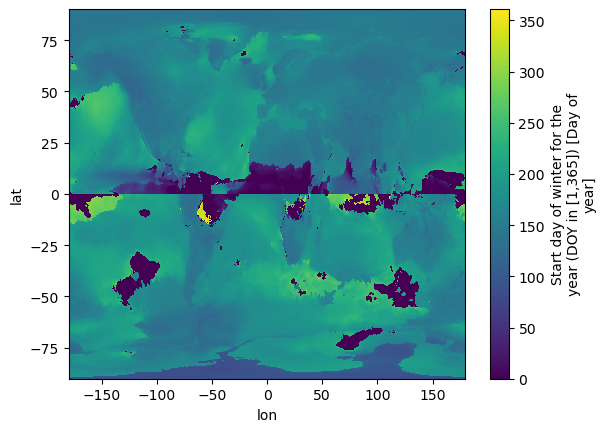

In [21]:
test.WinterStart.plot()